In [40]:
from dotenv import load_dotenv    
import os                         

load_dotenv()                                         

  

True

In [41]:
                  

from langchain_openai import ChatOpenAI                          
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage  
from langgraph.graph import StateGraph, START, END               
from langgraph.graph.message import add_messages    
from langgraph.checkpoint.memory import InMemorySaver  
from langgraph.checkpoint.sqlite import SqliteSaver           
from typing import TypedDict, Annotated                          

  

In [42]:
llm = ChatOpenAI(
    model="gpt-4o-mini",                          
    api_key=os.getenv("API_TOKEN"),               
    base_url="https://openrouter.ai/api/v1",      
    temperature=0.7,                               
)


response = llm.invoke("Say hello in one sentence.")
print(f" LLM works: {response.content}")

 LLM works: Hello! How can I assist you today?


In [43]:
class ChatState(TypedDict):
    messages: Annotated[list, add_messages] 

In [44]:
def chatbot_node(state: ChatState) -> dict:
    """The brain — sends conversation history to the LLM and returns its response."""
    
   
    system = SystemMessage(
        content="""You are a helpful, friendly AI assistant. 
        Remember everything the user tells you in this conversation.
        Keep responses concise (2-4 sentences for simple questions).
        Use emoji occasionally 😊"""
    )
    
    
    response = llm.invoke([system] + state["messages"])
    
    
    return {"messages": [response]}

In [45]:
graph_builder = StateGraph(ChatState)

In [46]:
graph_builder.add_node("chatbot", chatbot_node)

In [47]:
graph_builder.add_edge(START, "chatbot")           
graph_builder.add_edge("chatbot", END) 

In [48]:
with SqliteSaver.from_conn_string("checkpoints.db") as memory:
    graph = graph_builder.compile(checkpointer=memory)
    
    def chat():
        config = {"configurable": {"thread_id": "interactive_session"}}
        
        print("=" * 50)
        print(" LangGraph Chat (type 'quit' to exit)")
        print("=" * 50)
        
        turn = 0
        while True:
            try:
                user_input = input("\nYou: ").strip()
            except (KeyboardInterrupt, EOFError):
                print("\n Bye!")
                break
            
            if not user_input:
                continue
            if user_input.lower() in ["quit", "exit", "q"]:
                print(f"\n Goodbye! ({turn} turns)")
                break
            if user_input.lower() == "history":
                try:
                    st = graph.get_state(config)
                    msgs = st.values.get("messages", [])
                    print(f"\n History ({len(msgs)} messages):")
                    for i, m in enumerate(msgs, 1):
                        role = "You" if isinstance(m, HumanMessage) else "AI"
                        print(f"  [{i}] {role}: {m.content[:100]}")
                except:
                    print("No history yet.")
                continue
            
            turn += 1
            try:
                result = graph.invoke(
                    {"messages": [HumanMessage(content=user_input)]},
                    config=config
                )
                print(f"AI:  {result['messages'][-1].content}")
            except Exception as e:
                print(f"❌ Error: {e}")
    
    chat()

 LangGraph Chat (type 'quit' to exit)
AI:  Your nationality is Nigerian. If you have more questions or need assistance with something else, feel free to ask! 😊
AI:  Your name is Miracle! 😊
AI:  Your sex is male. If you have any more questions, feel free to ask! 😊

 Goodbye! (3 turns)


In [49]:
# memory = InMemorySaver()                            
# graph = graph_builder.compile(checkpointer=memory)
    
    

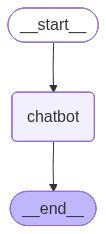

Graph displayed successfully.


In [50]:
try:
    from IPython.display import display, Image
    display(Image(graph.get_graph().draw_mermaid_png()))
    print("Graph displayed successfully.")
except Exception as e:
    print(f"Visualization not available: {e}")


In [51]:
tech_config = {"configurable": {"thread_id": "tech_thread"}}

result = graph.invoke(
    {"messages": [HumanMessage(content="My name is James and I'm learning LangGraph!")]},
    config=tech_config
)

print("You: My name is James and I'm learning LangGraph!")
print(f"AI:  {result['messages'][-1].content}")

ProgrammingError: Cannot operate on a closed database.

In [ ]:
result2 = graph.invoke(
    {"messages": [HumanMessage(content="What's my name and what am I learning?")]},
    config=tech_config             
)

print("You: What's my name and what am I learning?")
print(f"AI:  {result2['messages'][-1].content}")

You: What's my name and what am I learning?
AI:  Your name is James, and you’re learning LangGraph! 😊


In [ ]:
finance_config = {"configurable": {"thread_id": "finance_thread"}}

result = graph.invoke(
    {"messages": [HumanMessage(content="My name is James and I'm learning LangGraph!")]},
    config=finance_config
)

In [ ]:
state = graph.get_state(tech_config)
messages = state.values["messages"]

print(f"Full conversation ({len(messages)} messages):\n")
for i, msg in enumerate(messages, 1):
    role = "👤 You" if isinstance(msg, HumanMessage) else " AI"
    content = msg.content[:120] + "..." if len(msg.content) > 120 else msg.content
    print(f"  [{i}] {role}: {content}")

Full conversation (4 messages):

  [1] 👤 You: My name is James and I'm learning LangGraph!
  [2]  AI: Nice to meet you, James! 😊 LangGraph sounds interesting! What specifically are you learning about it?
  [3] 👤 You: What's my name and what am I learning?
  [4]  AI: Your name is James, and you’re learning LangGraph! 😊


In [ ]:
fresh_config = {"configurable": {"thread_id": "brand_new_thread"}}

result3 = graph.invoke(
    {"messages": [HumanMessage(content="What's my name?")]},
    config=fresh_config         
)

print("You: What's my name? (new thread — AI has no memory)")
print(f"AI:  {result3['messages'][-1].content}")
print("\n☝️  See? Different thread_id = the AI doesn't remember anything!")


You: What's my name? (new thread — AI has no memory)
AI:  I don't know your name yet! If you tell me, I'll remember it for our conversation. 😊

☝️  See? Different thread_id = the AI doesn't remember anything!


In [ ]:
def chat():
    """Full interactive chat with memory."""
    
    config = {"configurable": {"thread_id": "interactive_session"}}
    
    print("=" * 50)
    print(" LangGraph Chat (type 'quit' to exit)")
    print("=" * 50)
    
    turn = 0
    while True:
        try:
            user_input = input("\nYou: ").strip()
        except (KeyboardInterrupt, EOFError):
            print("\n Bye!")
            break
        
        if not user_input:
            continue
        if user_input.lower() in ["quit", "exit", "q"]:
            print(f"\n Goodbye! ({turn} turns)")
            break
        if user_input.lower() == "history":
            try:
                st = graph.get_state(config)
                msgs = st.values.get("messages", [])
                print(f"\n History ({len(msgs)} messages):")
                for i, m in enumerate(msgs, 1):
                    role = "You" if isinstance(m, HumanMessage) else "AI"
                    print(f"  [{i}] {role}: {m.content[:100]}")
            except:
                print("No history yet.")
            continue
        
        turn += 1
        try:
            result = graph.invoke(
                {"messages": [HumanMessage(content=user_input)]},
                config=config
            )
            print(f"AI:  {result['messages'][-1].content}")
        except Exception as e:
            print(f"❌ Error: {e}")

In [ ]:
chat()

 LangGraph Chat (type 'quit' to exit)
AI:  "Miracle" can refer to different things depending on the context. It could refer to a miraculous event, a product, or even a character in a story. Could you specify what you're referring to? 😊

 Goodbye! (1 turns)
